# Sunset Grade Distributions Over Time

This notebook is for the Sunset time-series analysis.



In [1]:
from pathlib import Path
import sys

import pandas as pd

cwd = Path.cwd().resolve()
root_dir = next((path for path in [cwd, *cwd.parents] if (path / "src").exists() and (path / "data" / "sunset_data.csv").exists()), None)
if root_dir is None:
    raise FileNotFoundError("Could not find the project root from the current notebook working directory.")
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.sunset_analysis import load_provider_releases, load_sunset_data, prepare_group_term_data, preview_sunset_frame
from src.sunset_plotting import plot_group_trends, plot_group_trends_for_provider



## Load Data

Load the Sunset grade-distribution export and the provider release timelines used for the later overlays.


In [2]:
sunset_path = root_dir / "data" / "sunset_data.csv"
provider_release_paths = {
    "GPT": root_dir / "data" / "chatgpt_model_updates.csv",
    "Claude": root_dir / "data" / "claude_model_updates.csv",
    "Gemini": root_dir / "data" / "gemini_model_updates.csv",
    "Grok": root_dir / "data" / "grok_model_updates.csv",
}

sunset_df = load_sunset_data(sunset_path)
provider_releases = {
    provider: load_provider_releases(provider, path)
    for provider, path in provider_release_paths.items()
}

preview_sunset_frame(sunset_df)


,Submission time,User ID,Term,Course,Professor,Grade distribution,Recommend professor?
0,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Fall Qtr 2023,CSE 167,"Li, Tzumao","A+:102, A:22, A-:11, B+:5, B:7, B-:6, C+:2, C:...",NaN
1,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Spring Qtr 2023,CSE 101,"Jones, Miles E","A+:44, A:63, A-:45, B+:27, B:19, B-:11, C+:8, ...",NaN
2,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Spring Qtr 2023,CSE 110,"Powell, Thomas Allan","A+:0, A:17, A-:7, B+:9, B:6, B-:4, C+:1, C:0, ...",NaN
3,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Spring Qtr 2023,PHYS 2C,"Yang, Liang","A+:0, A:4, A-:3, B+:3, B:5, B-:6, C+:4, C:2, C...",NaN
4,2023-12-23T05:50:18.840Z,259100ef37d22fcae62b973b4933094bcee3496ac77926...,Winter Qtr 2023,CAT 125,"Bigham, David Joseph","A+:0, A:14, A-:4, B+:1, B:0, B-:0, C+:0, C:0, ...",NaN


## Build Quarterly Department Groups

Filter the raw Sunset rows, merge related departments into broader groups, and keep only groups with enough quarter coverage for a stable time-series view.


In [5]:
group_term, coverage_table, selected_groups = prepare_group_term_data(sunset_df)

print(f"Selected groups ({len(selected_groups)}): {selected_groups}")
coverage_table[coverage_table["Group"].isin(selected_groups)]


Selected groups (10): ['Computing & EECS', 'Math & Logic', 'Physical Sciences', 'Writing & Humanities', 'Languages', 'Social Sciences', 'Life Sciences', 'Arts & Media', 'Econ & Management', 'Engineering']


,Group,Quarter_Count,First_Term,Last_Term,Class_Count,Letter_Outcomes
0,Computing & EECS,19,Fall Qtr 2019,Fall Qtr 2025,1378,150183.0
1,Math & Logic,19,Fall Qtr 2019,Fall Qtr 2025,1117,43433.0
2,Physical Sciences,19,Fall Qtr 2019,Fall Qtr 2025,873,51177.0
3,Writing & Humanities,19,Fall Qtr 2019,Fall Qtr 2025,723,14546.0
4,Languages,19,Fall Qtr 2019,Fall Qtr 2025,179,3655.0
5,Social Sciences,18,Fall Qtr 2019,Fall Qtr 2025,573,53816.0
6,Life Sciences,18,Fall Qtr 2019,Fall Qtr 2025,349,22969.0
7,Arts & Media,18,Winter Qtr 2020,Fall Qtr 2025,256,11483.0
8,Econ & Management,17,Fall Qtr 2019,Fall Qtr 2025,176,14660.0
9,Engineering,15,Fall Qtr 2020,Fall Qtr 2025,219,15799.0


## Grade-Band Trends

These figures track the percentage share of `A`, `B`, `C`, and `D/F` grades over time for each merged department group.
The first plot shows the time trend alone; the second adds all provider markers; the later section splits the release overlays by provider family.


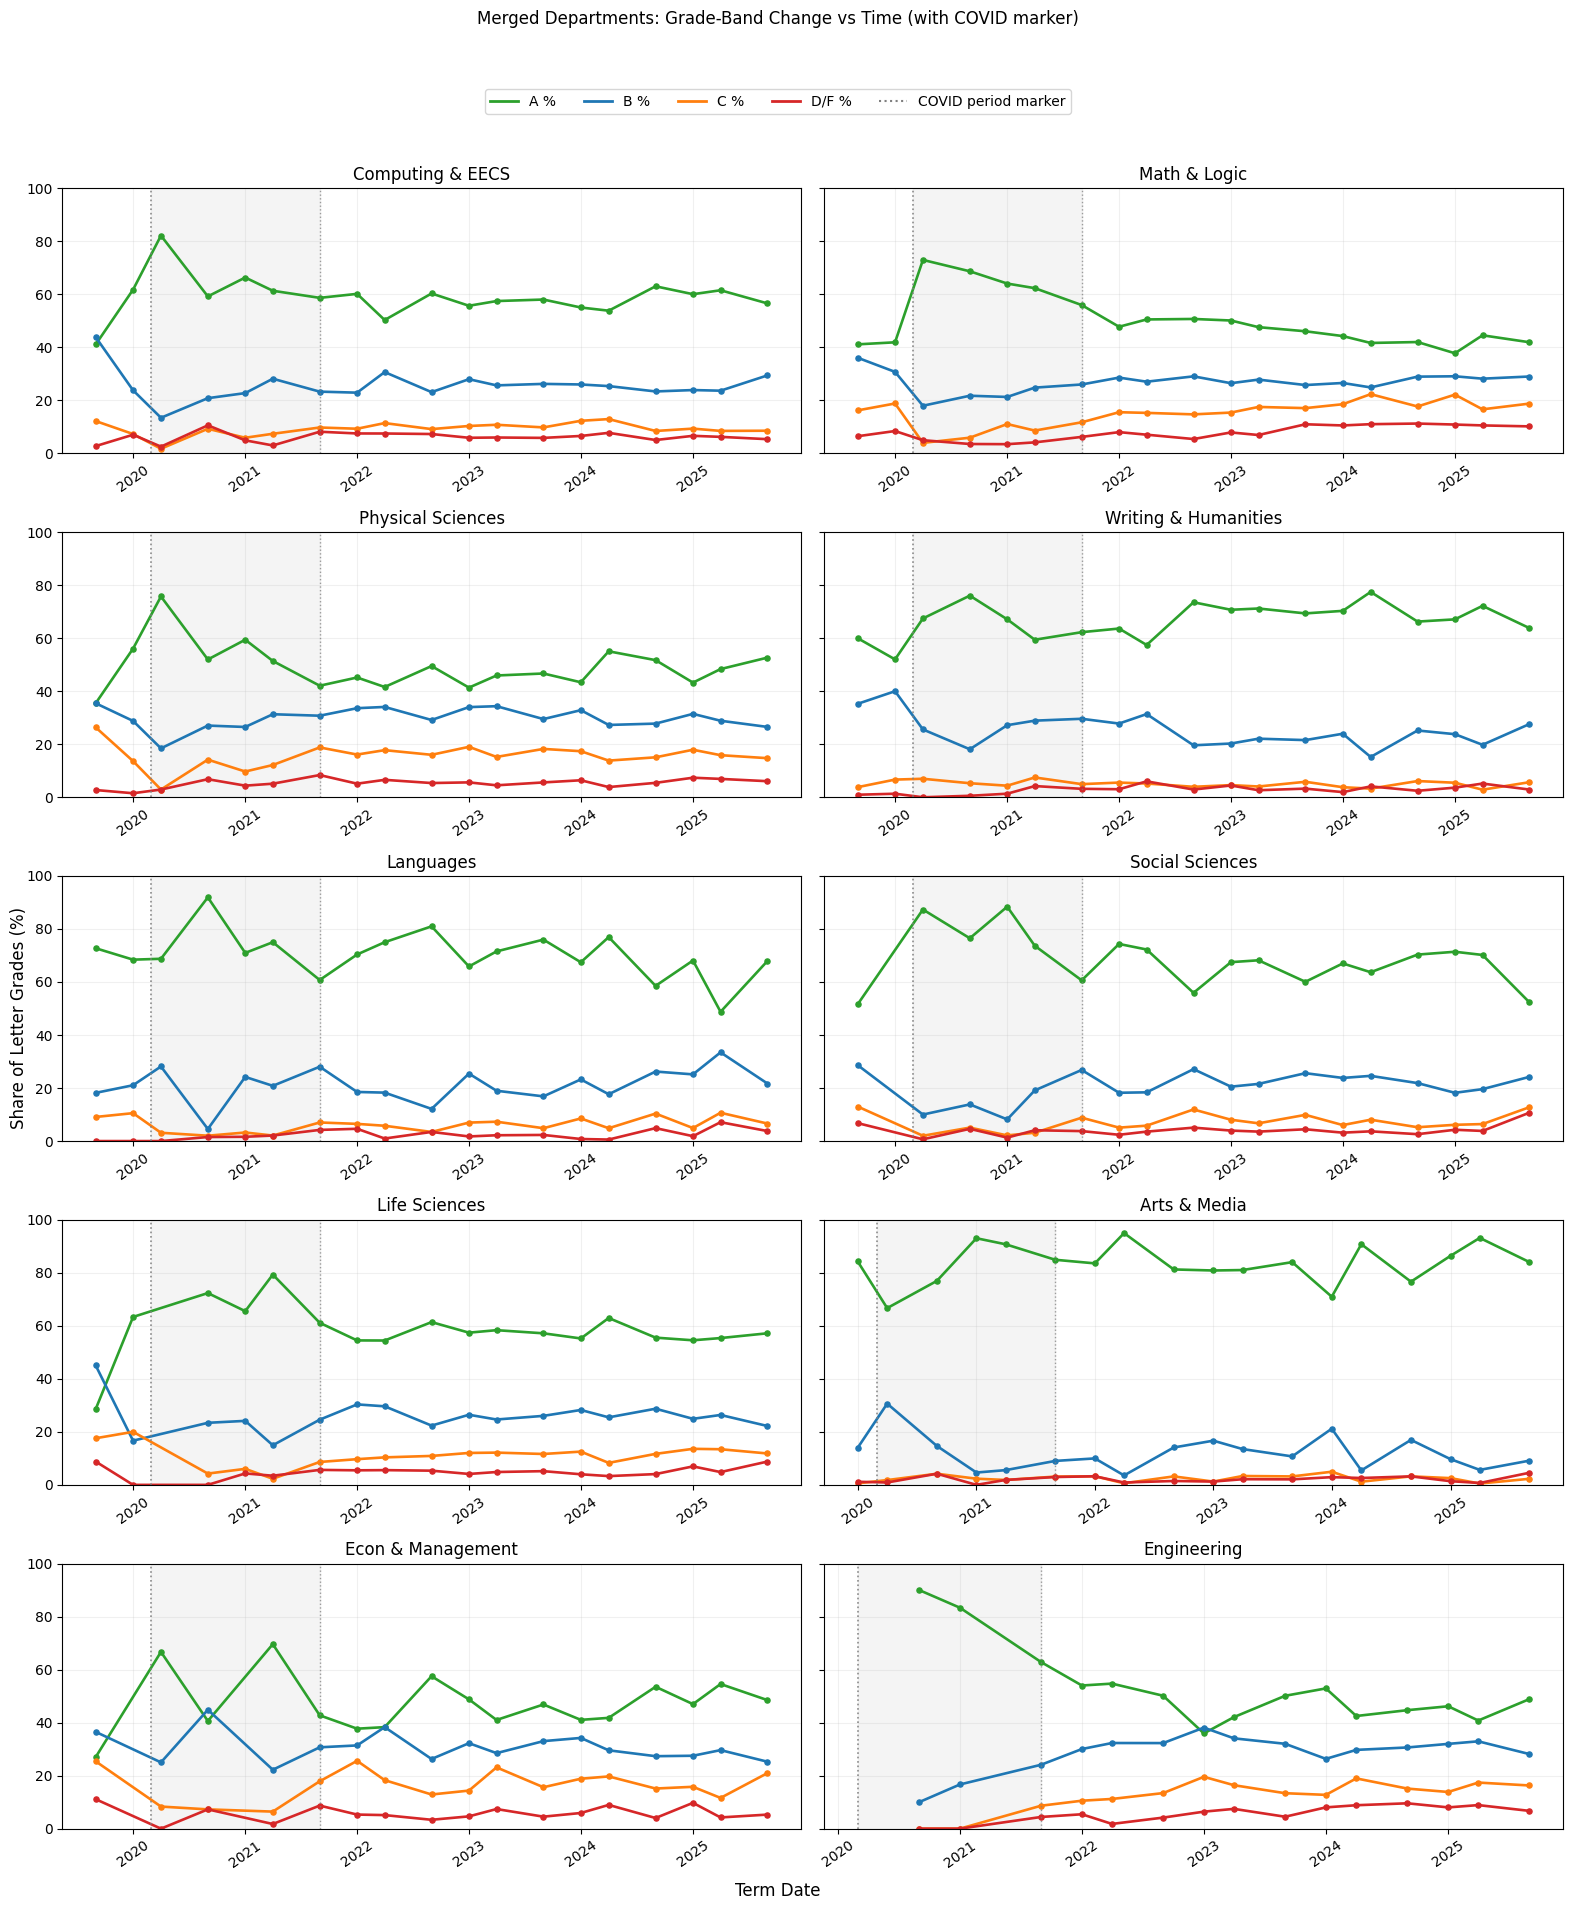

WindowsPath('figures/merged_groups_grade_change_vs_time.png')

In [7]:
# Plot set 1: grade-band changes vs time (no LLM overlay)
out1 = Path("figures") / "merged_groups_grade_change_vs_time.png"
plot_group_trends(group_term, selected_groups, with_llm_markers=False, save_path=out1)
out1


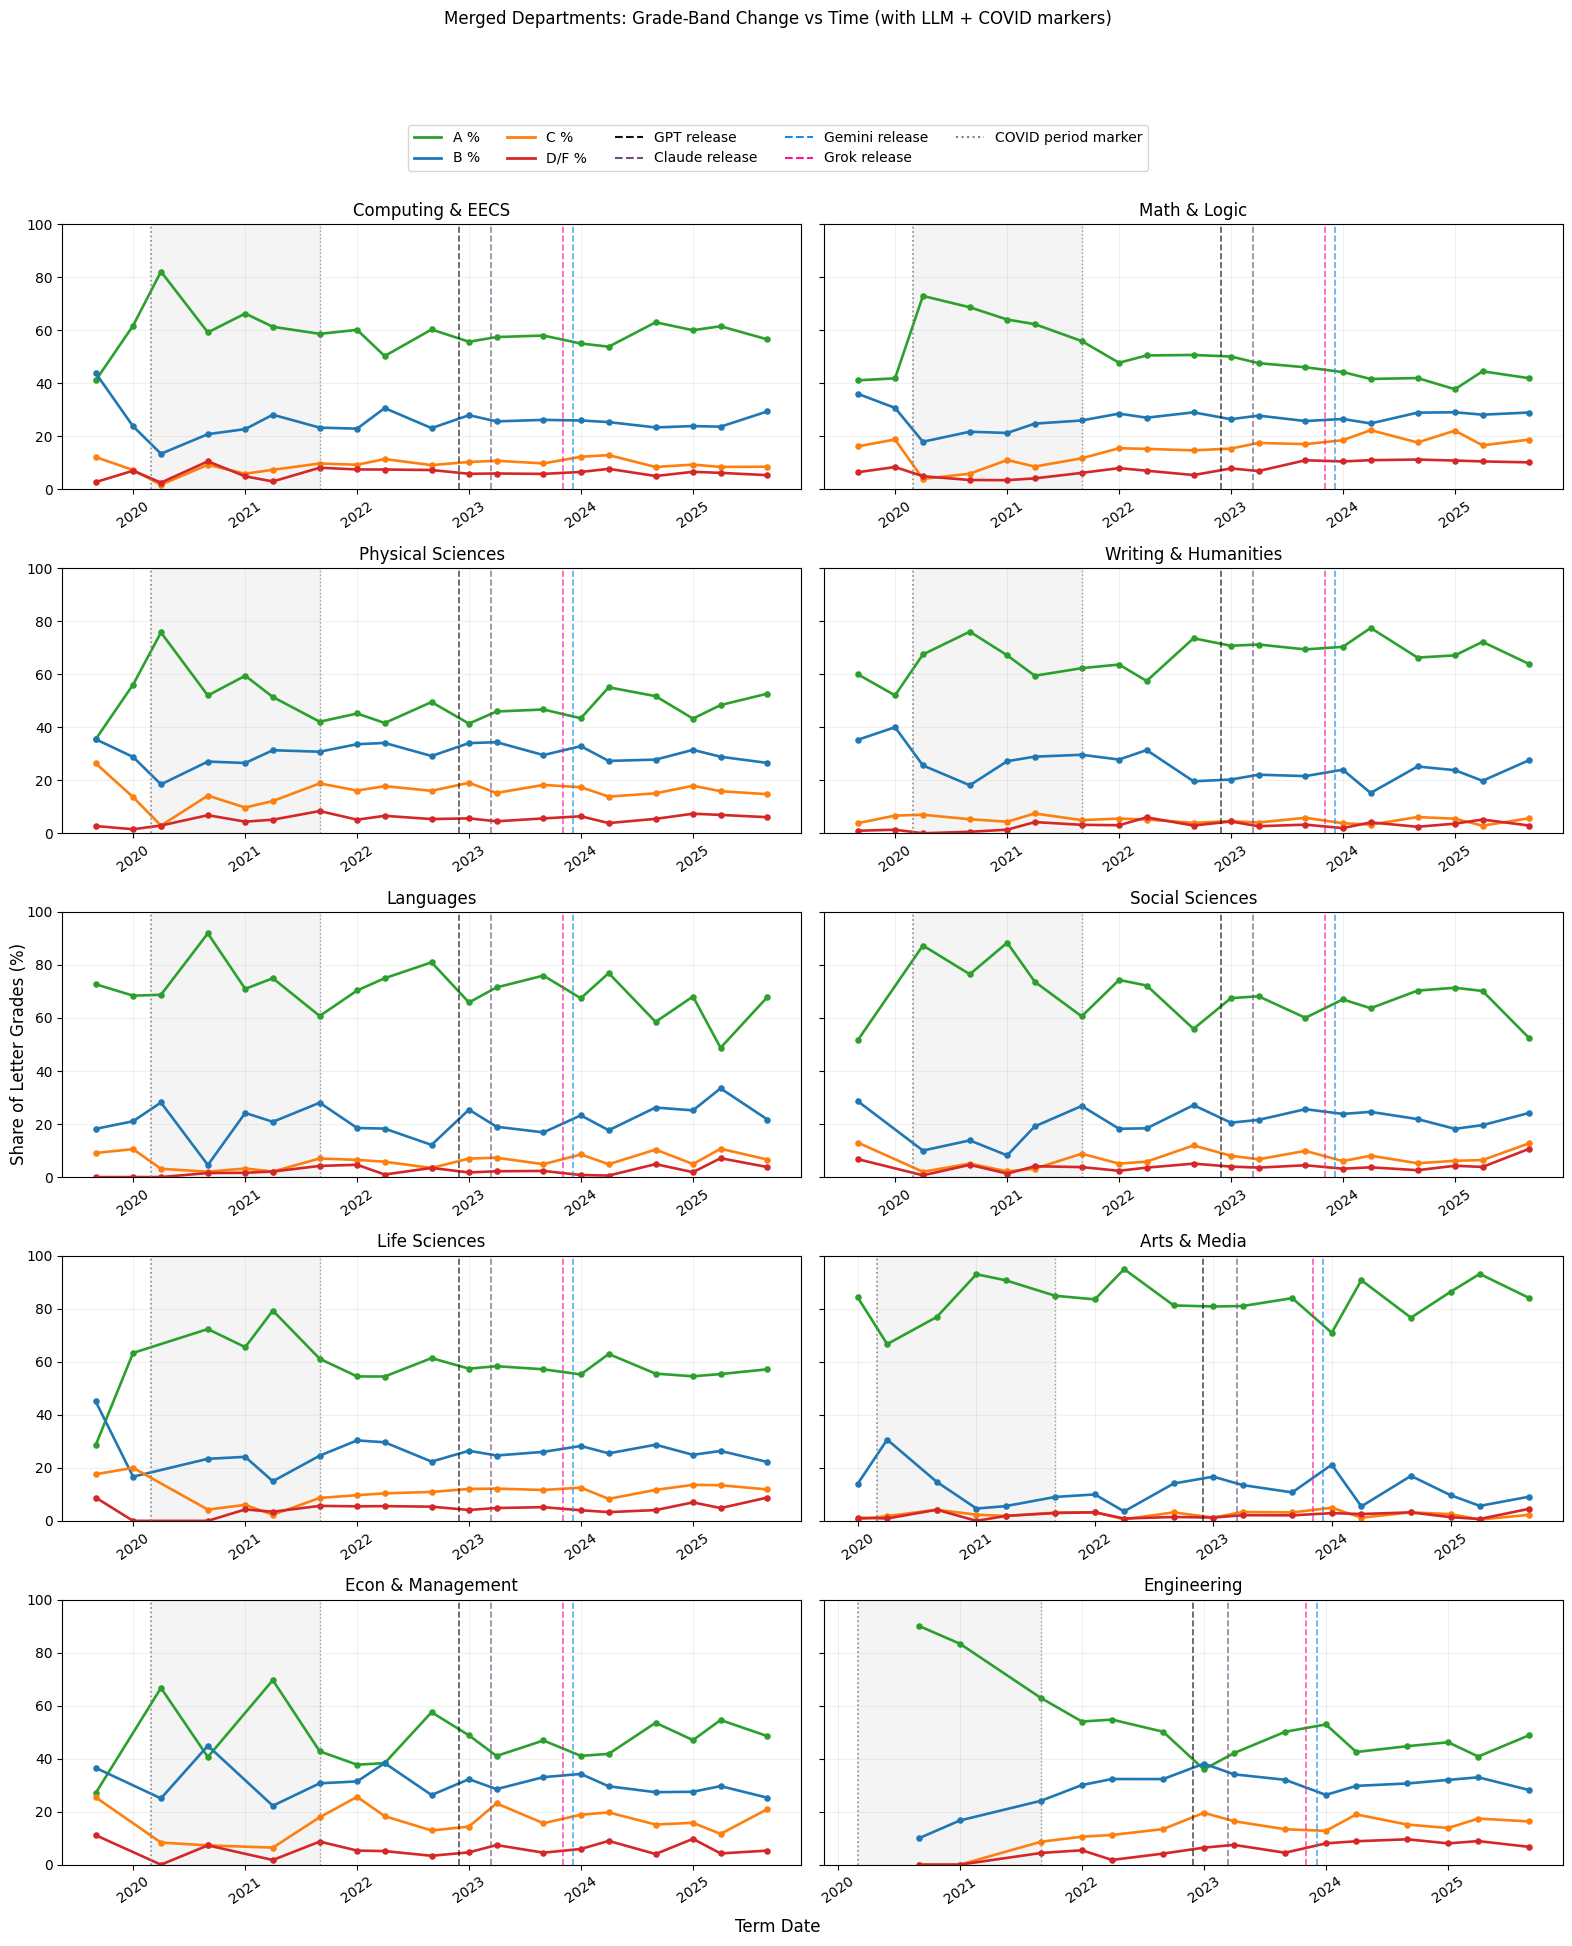

WindowsPath('figures/merged_groups_grade_change_with_llm_markers.png')

In [8]:
# Plot set 2: same grade-band trends + all four LLM markers (GPT/Claude/Gemini/Grok)
out2 = Path("figures") / "merged_groups_grade_change_with_llm_markers.png"
plot_group_trends(group_term, selected_groups, with_llm_markers=True, save_path=out2)
out2


In [9]:
pd.DataFrame({
    "Provider": list(provider_releases.keys()),
    "Release_Count": [len(df) for df in provider_releases.values()],
})


,Provider,Release_Count
0,GPT,11
1,Claude,9
2,Gemini,6
3,Grok,6


## Provider-Specific Release Timelines

Each provider plot marks the release dates for successive versions so the grade-band trends can be compared against model evolution, not just a single launch date.


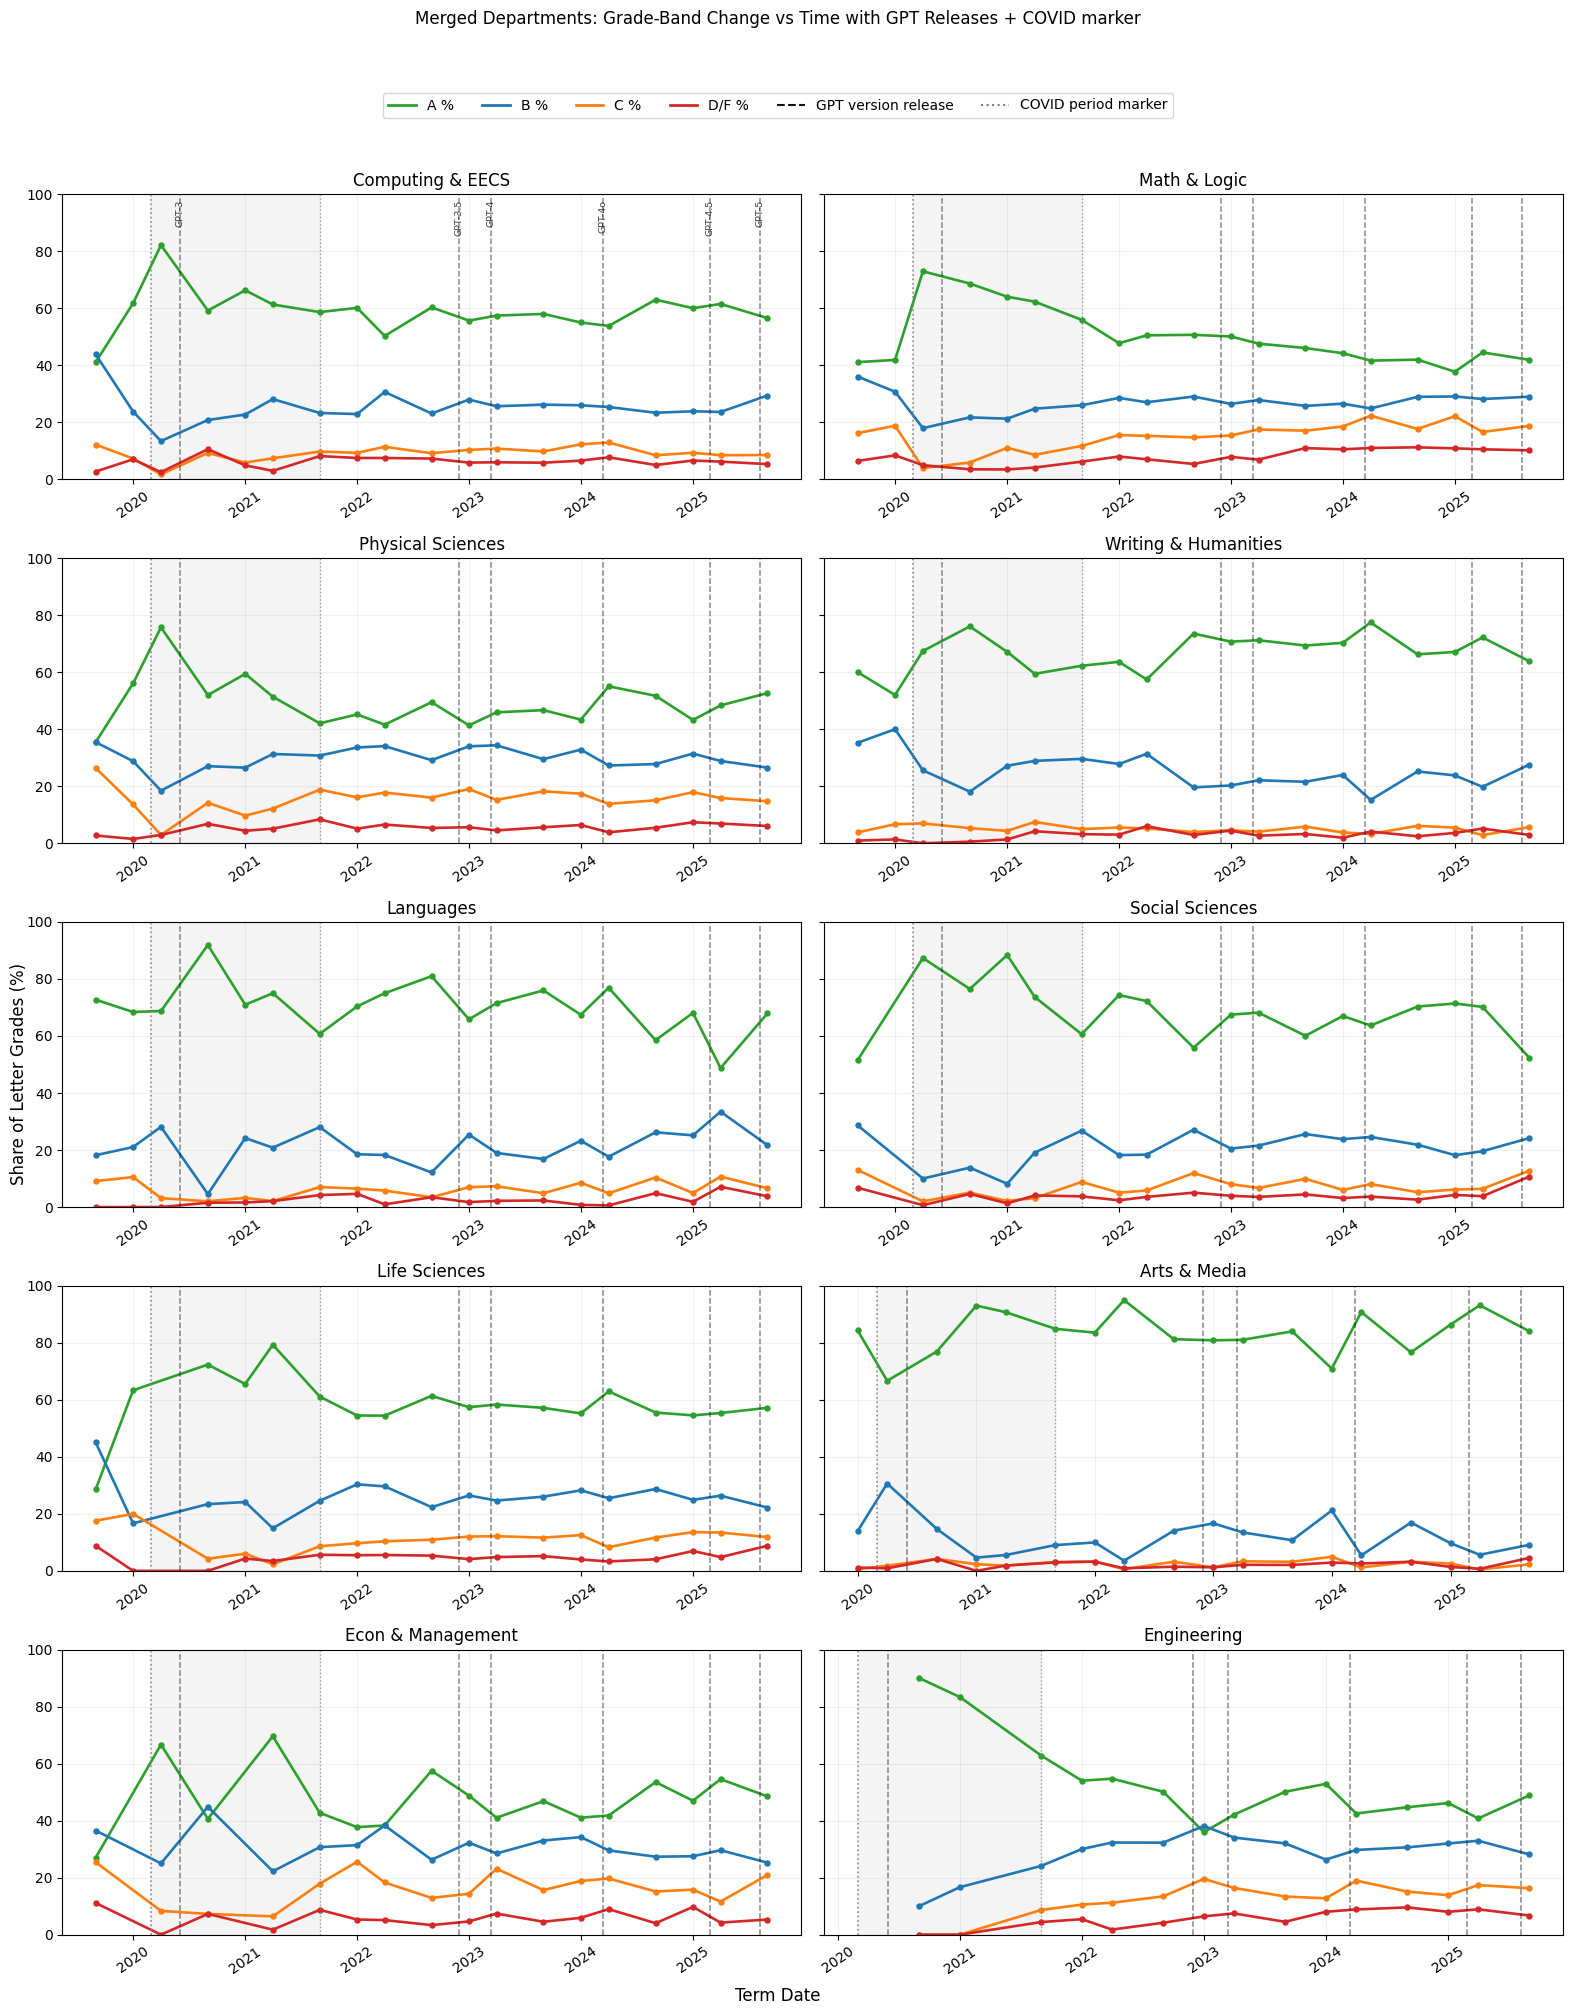

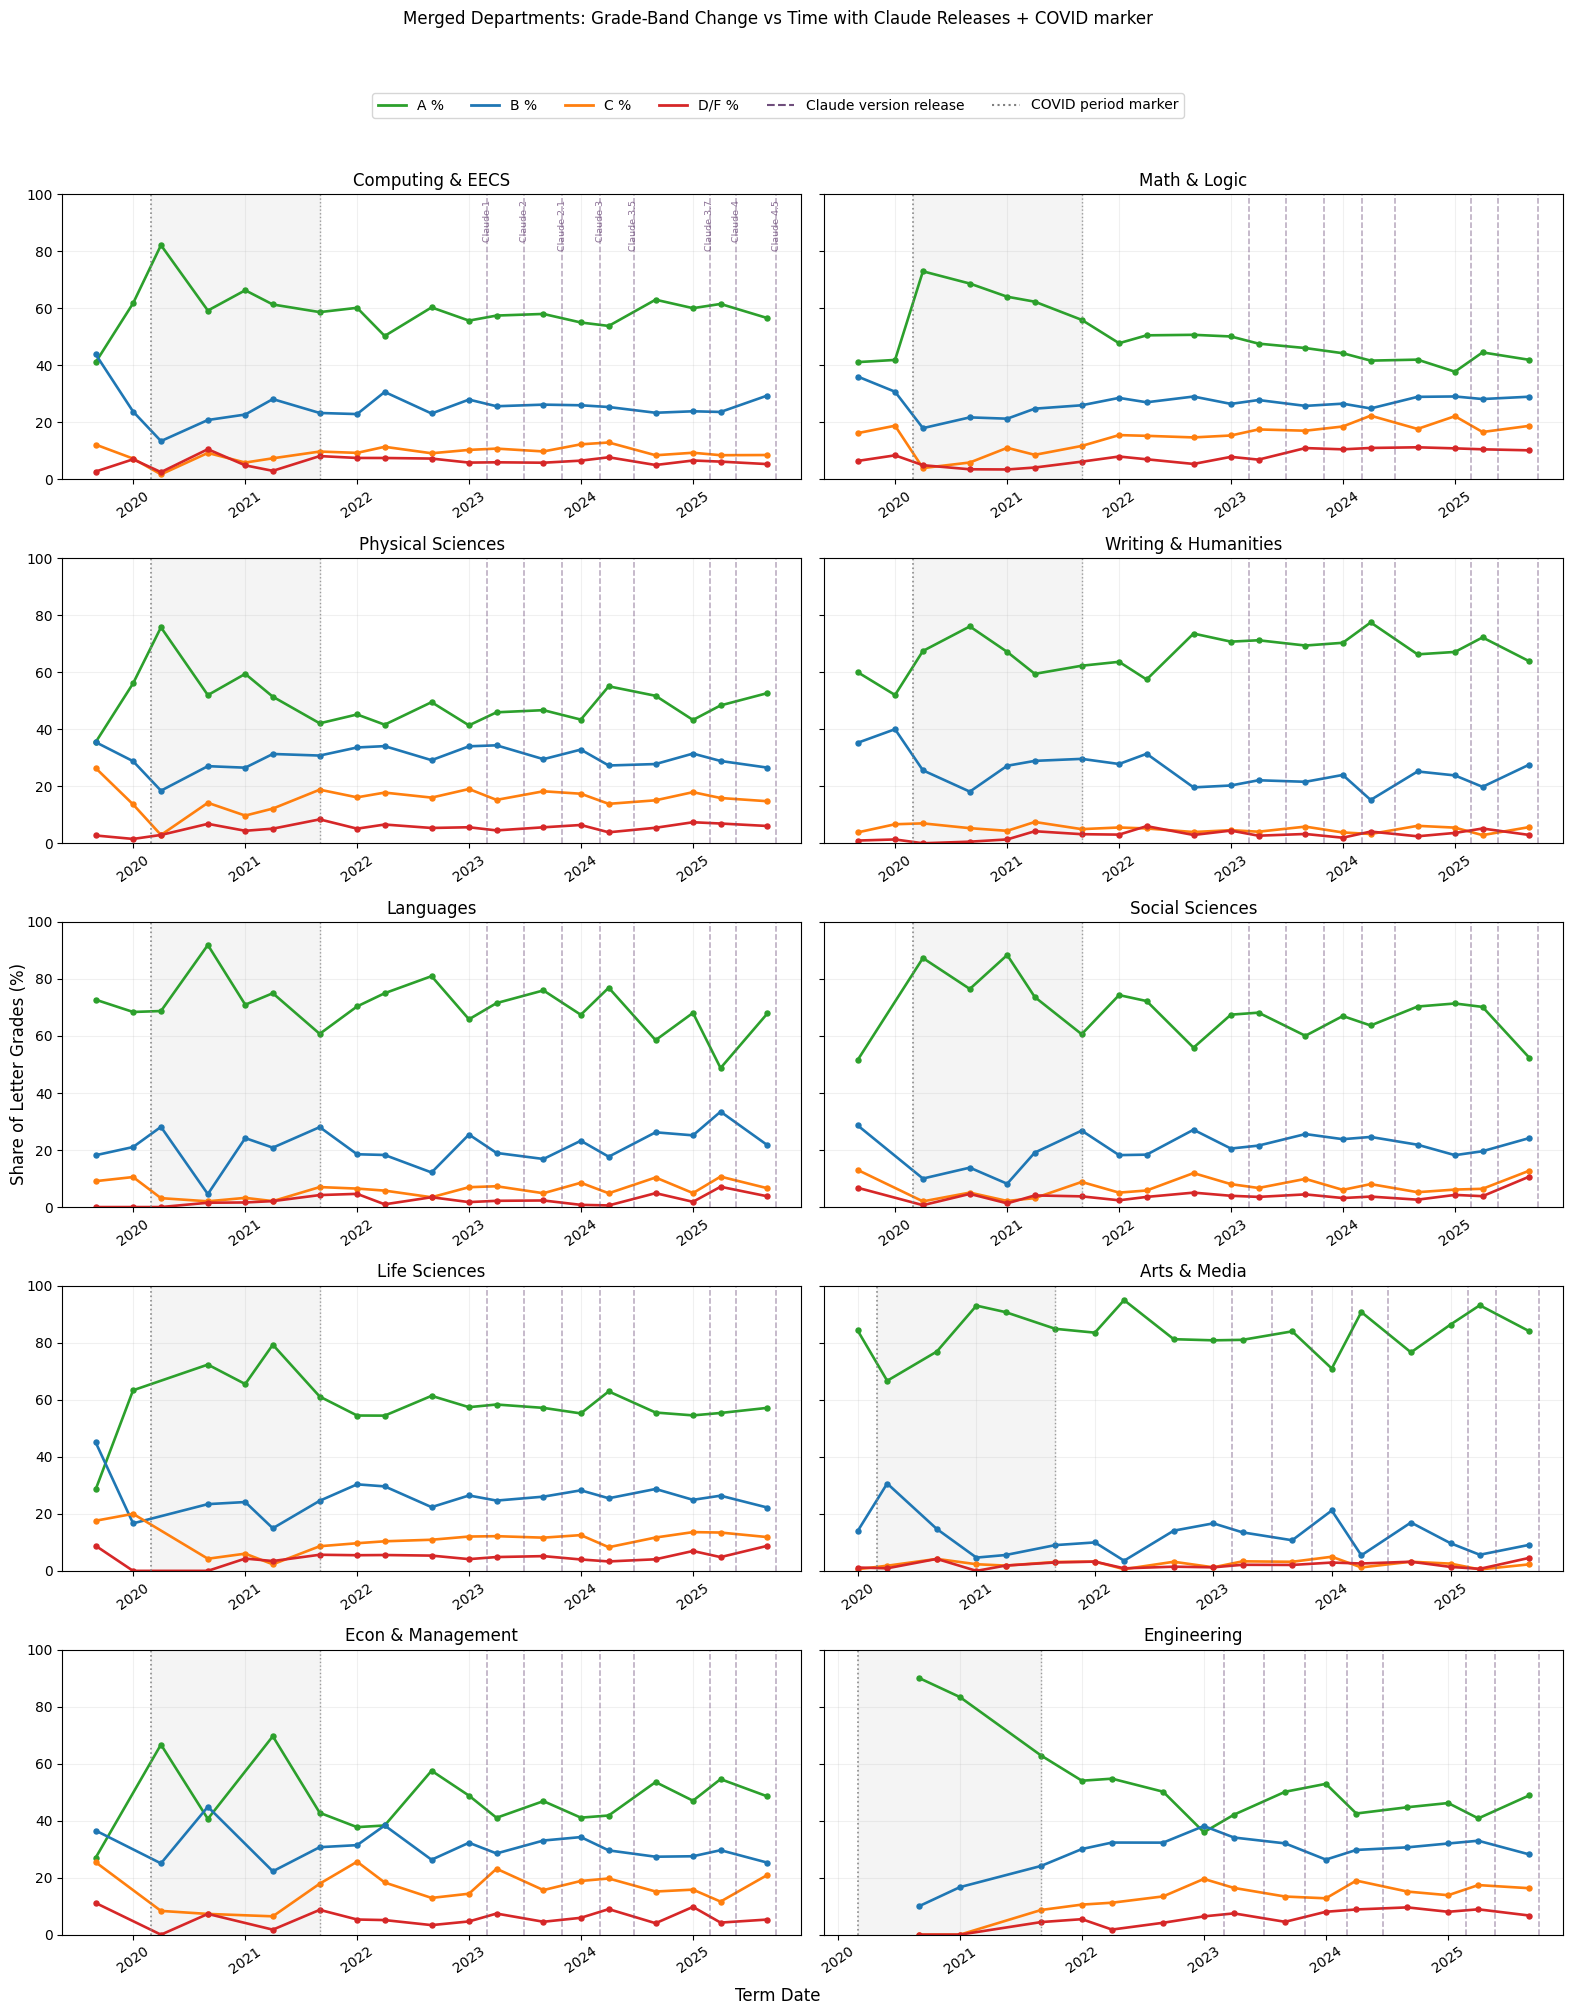

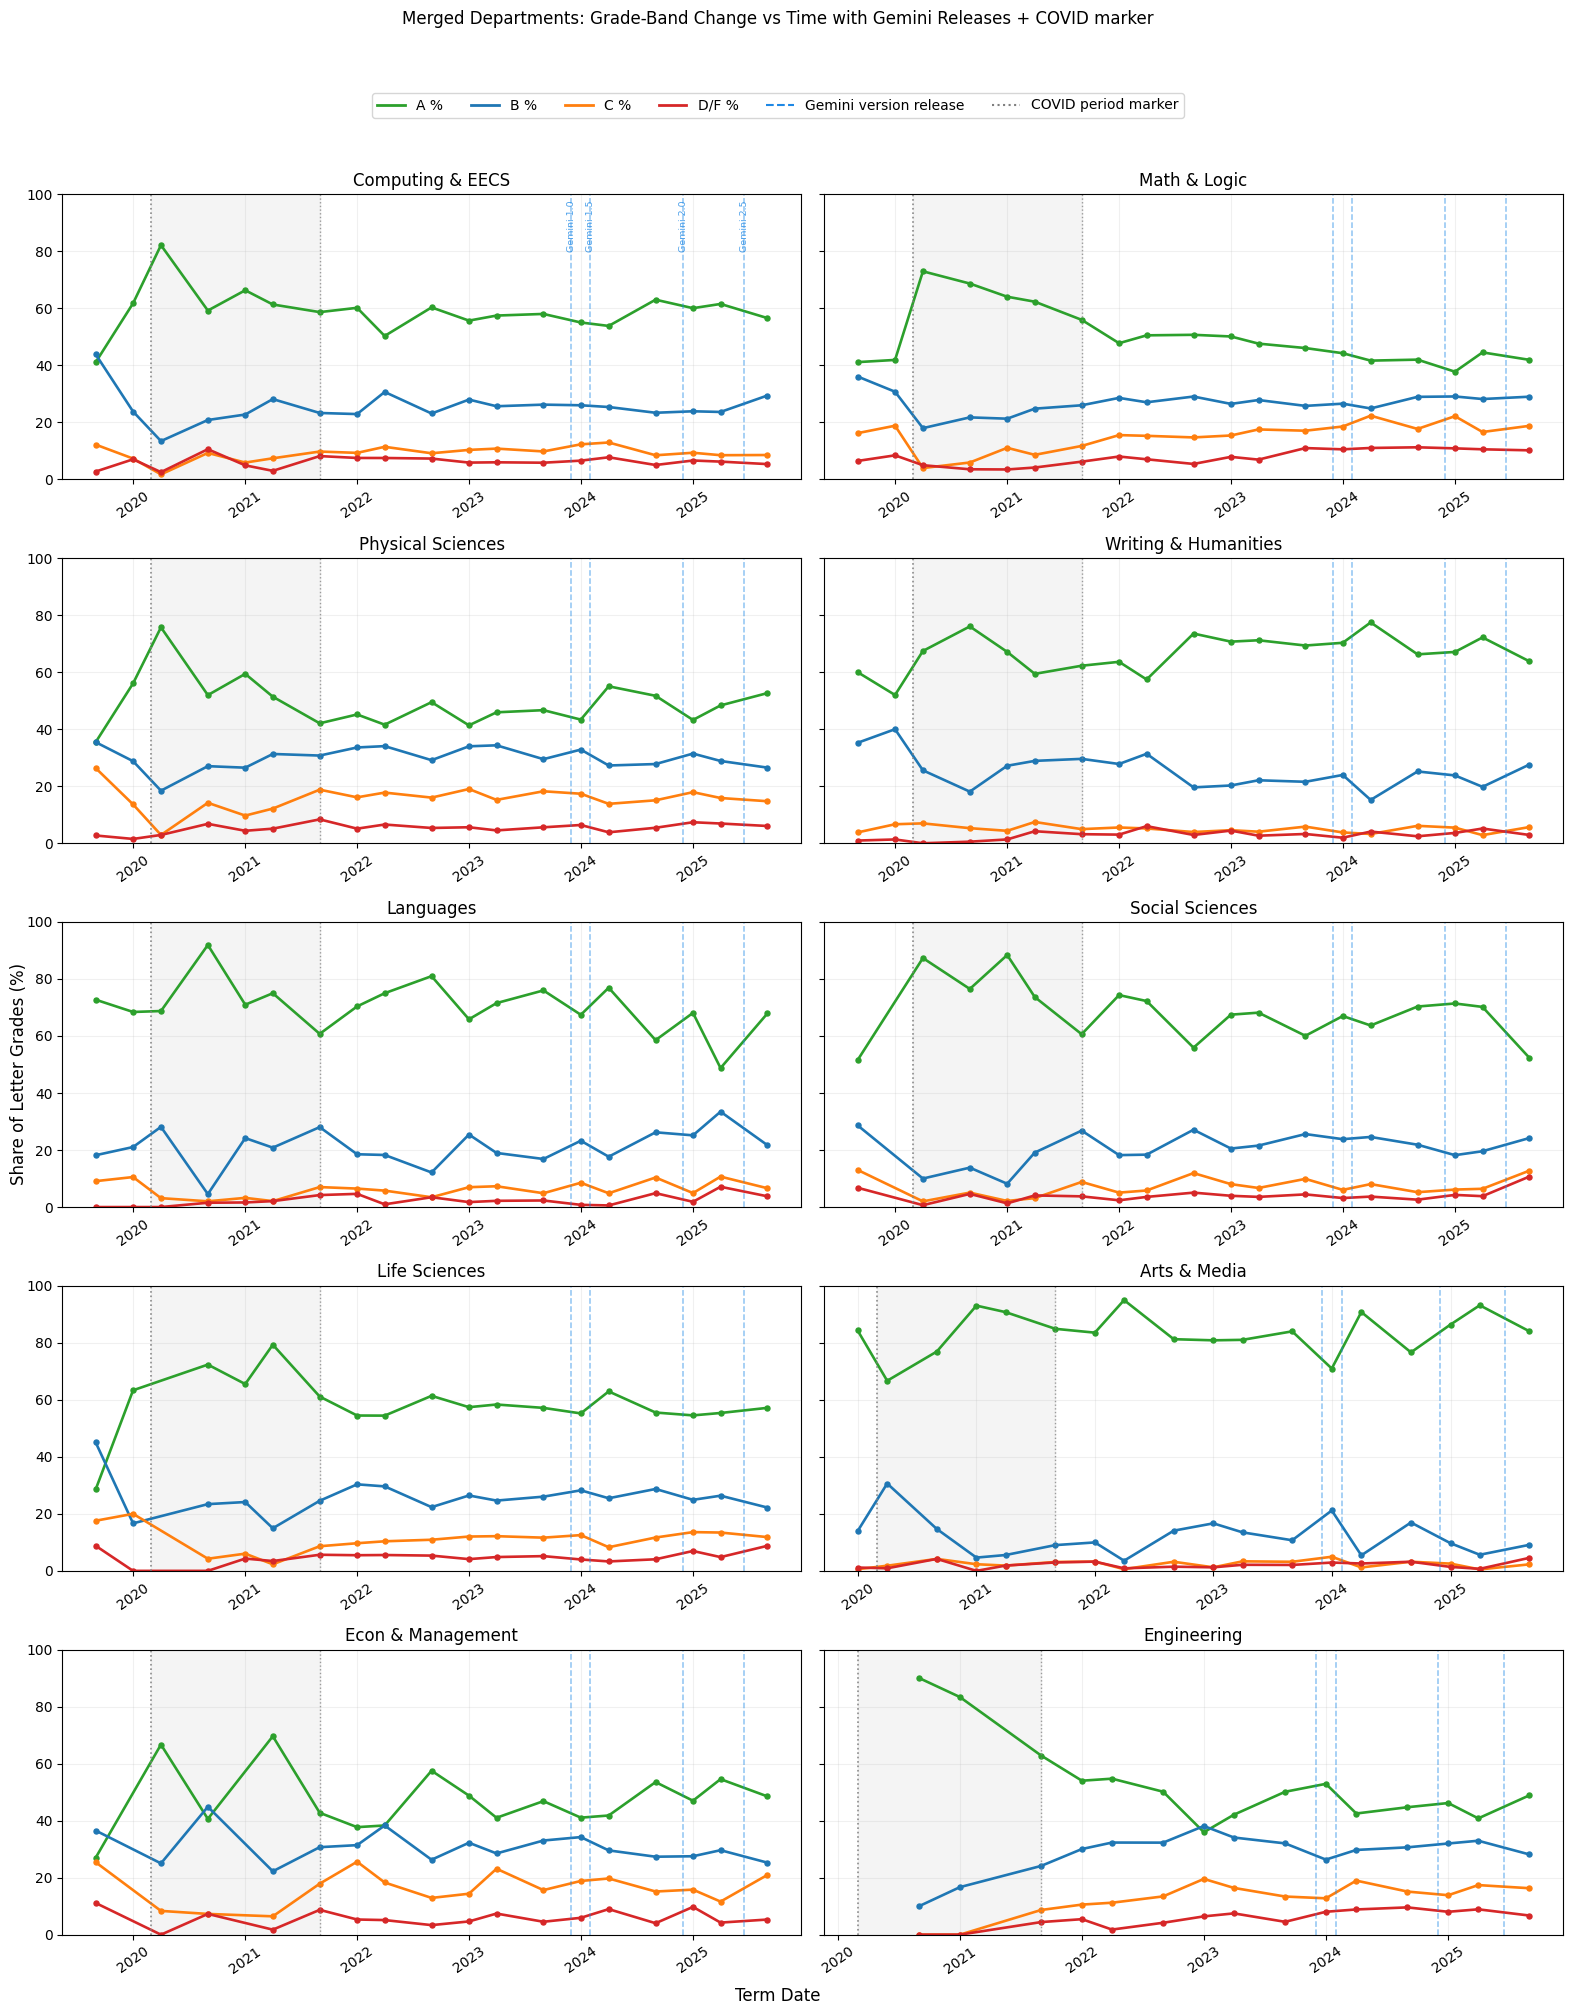

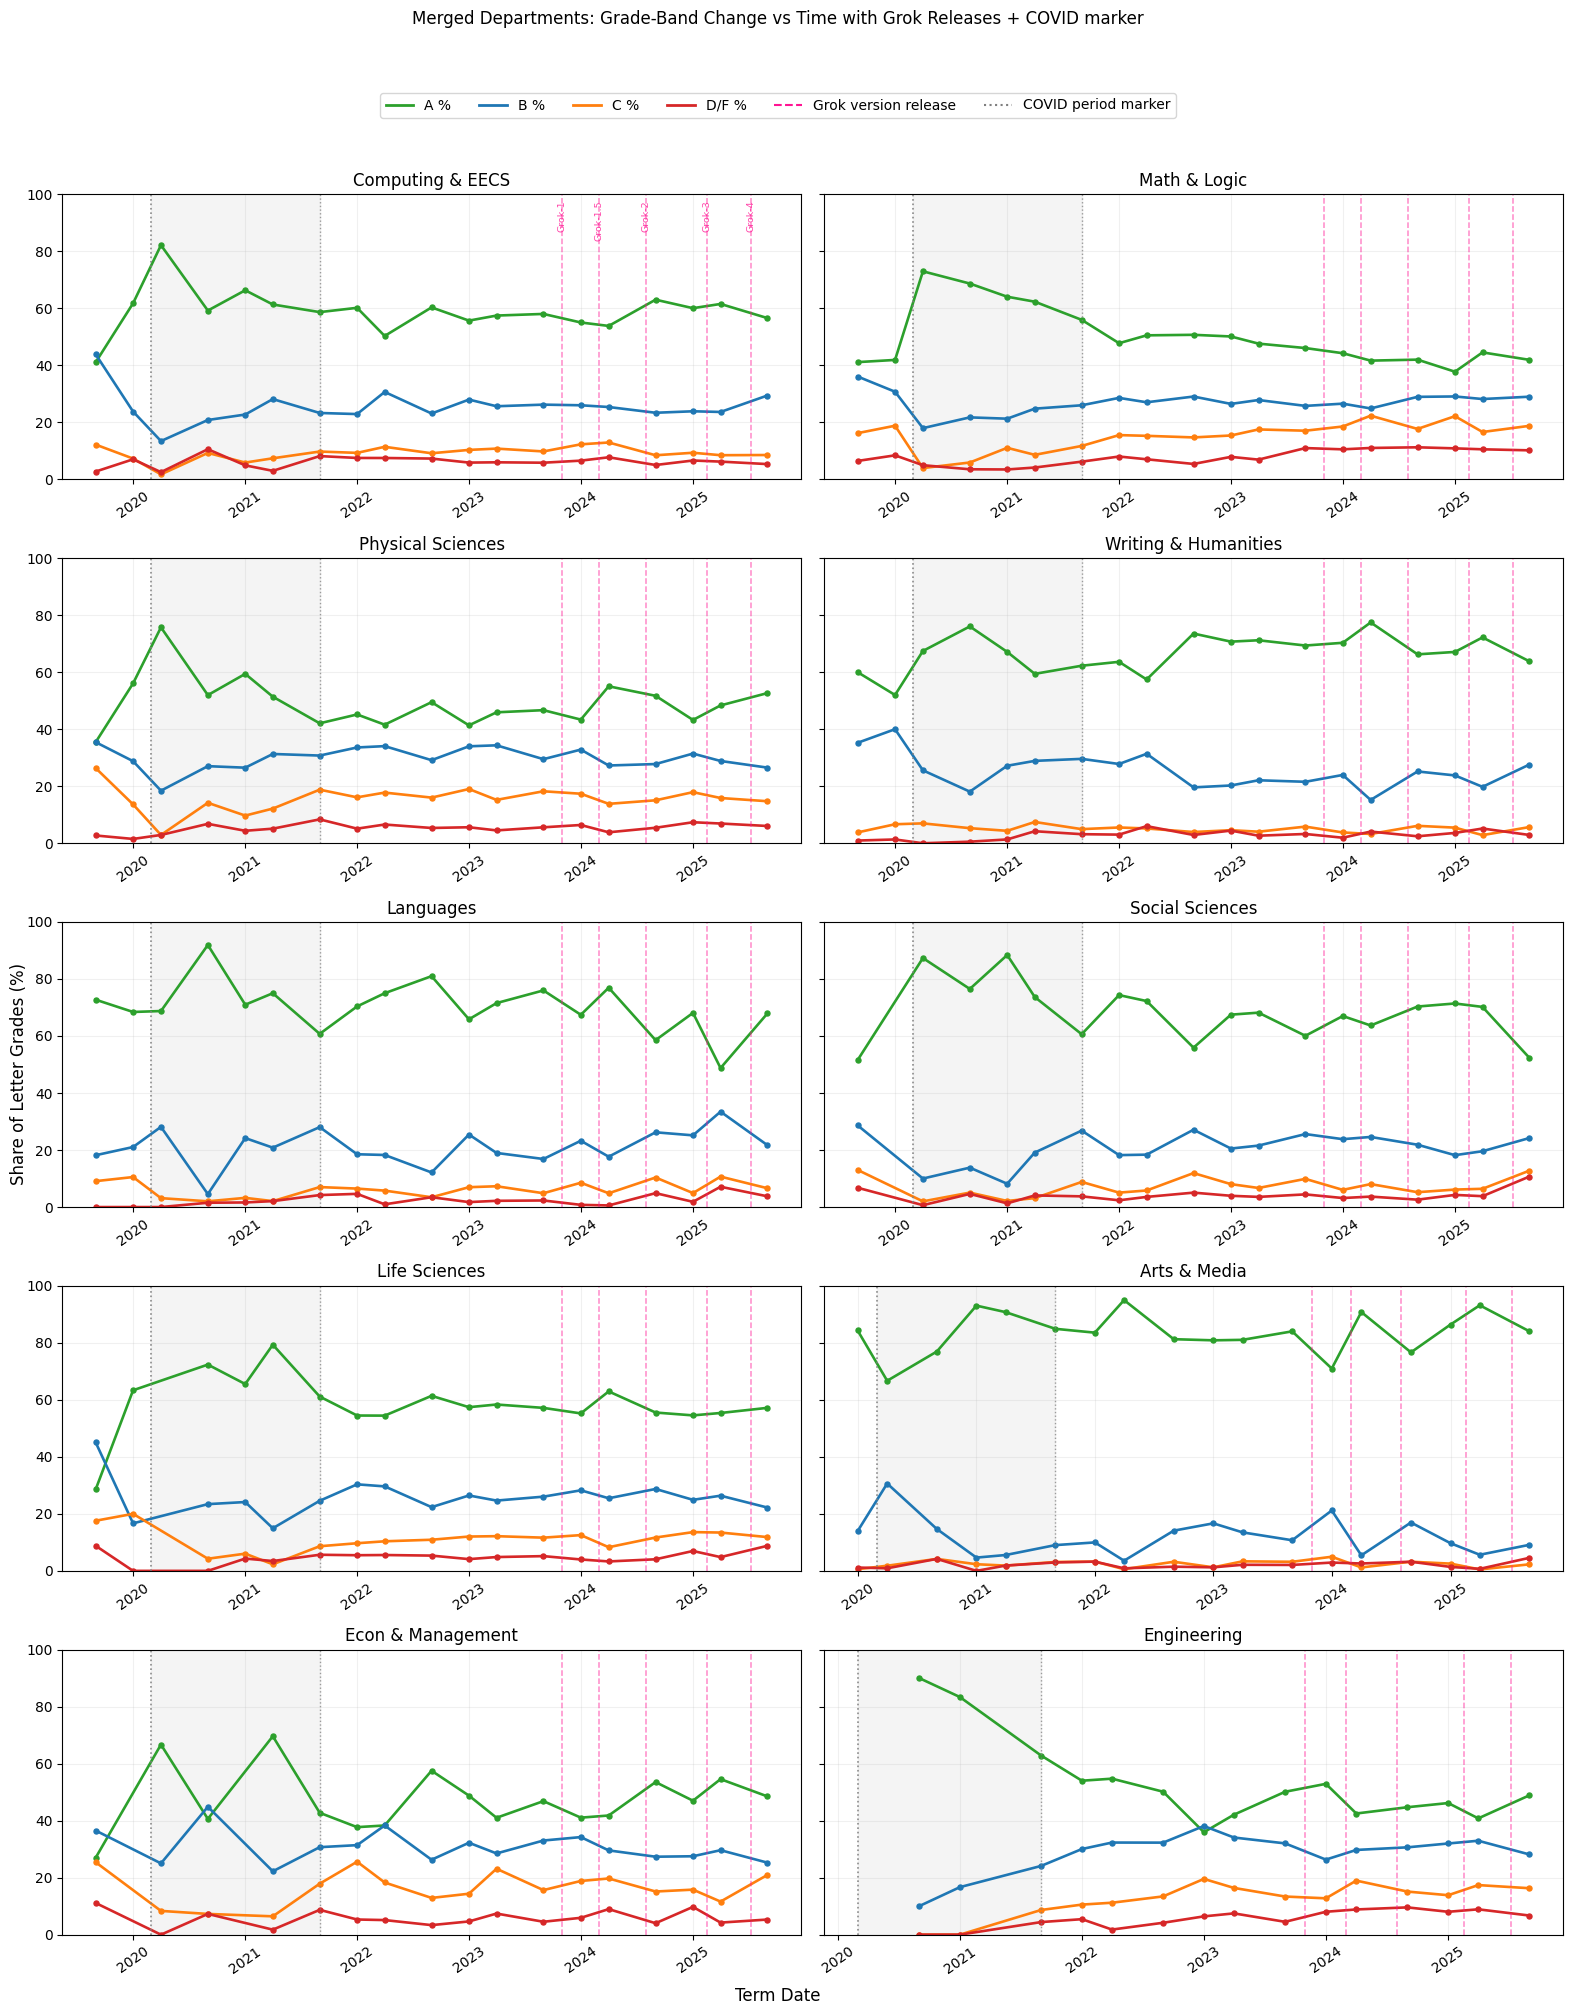

{'GPT': WindowsPath('figures/merged_groups_grade_change_gpt_versions.png'),
 'Claude': WindowsPath('figures/merged_groups_grade_change_claude_versions.png'),
 'Gemini': WindowsPath('figures/merged_groups_grade_change_gemini_versions.png'),
 'Grok': WindowsPath('figures/merged_groups_grade_change_grok_versions.png')}

In [11]:
# Plot set 3: one plot per provider with each version release marked
provider_plot_paths = {}
for provider in ["GPT", "Claude", "Gemini", "Grok"]:
    save_path = Path("figures") / f"merged_groups_grade_change_{provider.lower()}_versions.png"
    plot_group_trends_for_provider(
        group_term_df=group_term,
        groups=selected_groups,
        provider=provider,
        releases_df=provider_releases[provider],
        save_path=save_path,
    )
    provider_plot_paths[provider] = save_path

provider_plot_paths
